# Assignment 9.0 — Explore the Arena

Welcome to the RL assignment. Across three notebooks you will:

0. **(this notebook)** Get oriented with the environment and play it
   yourself.
1. **[`1-q_learning.ipynb`](1-q_learning.ipynb)** — train a tabular
   Q-learning agent.
2. **[`2-deep_q_learning.ipynb`](2-deep_q_learning.ipynb)** — train a
   Deep Q-Network on the same env and compare.

## The arena

`arena.JumperEnv` is a tiny Chrome-Dino-style runner. The agent (red
rectangle) runs at constant horizontal speed; obstacles (green
rectangles) scroll in from the right. Two actions:

| action | name |
| ------ | ---- |
|  0     | `NOOP` |
|  1     | `JUMP` |

Observation (5-dim float vector):

    (player_height, player_vy, next_obs_dx, next_obs_w, speed)

Reward: `+0.1` per surviving step, `+1` per cleared obstacle, `-10`
on collision (terminates the episode). World speed grows slowly across
the episode, so the optimal policy depends on `speed` too.

The env is **Gymnasium-compatible** in signature —
`reset() -> (obs, info)` and
`step(action) -> (obs, reward, terminated, truncated, info)` —
but does not require `gymnasium` to be installed.

## 1. Reset and inspect a single observation

In [1]:
from arena import JumperEnv, Action

env = JumperEnv(seed=0)
obs, info = env.reset()
for name, value in zip(env.FEATURE_NAMES, obs):
    print(f"  {name:<15} {value:7.3f}")
print("info:", info)

  player_height     0.000
  player_vy         0.000
  next_obs_dx     144.000
  next_obs_w        9.000
  speed             2.000
info: {'score': 0, 'speed': 2.0, 'steps': 0}


## 2. Random-policy baseline

Roll out 100 episodes with a random policy. This is the floor both
learned agents have to beat.

In [2]:
import numpy as np

rng = np.random.default_rng(0)
steps_per_ep = []
scores = []
for ep in range(100):
    obs, _ = env.reset()
    steps = 0
    while True:
        a = int(rng.integers(0, 2))
        obs, r, term, trunc, info = env.step(a)
        steps += 1
        if term or trunc:
            break
    steps_per_ep.append(steps)
    scores.append(info["score"])

print(f"random baseline over 100 episodes:")
print(f"  mean steps : {np.mean(steps_per_ep):6.1f}  (std {np.std(steps_per_ep):.1f})")
print(f"  mean score : {np.mean(scores):6.2f}  (max {np.max(scores)})")

random baseline over 100 episodes:
  mean steps :   81.0  (std 14.0)
  mean score :   0.27  (max 3)


## 3. What does a frame look like?

The env can render an RGB frame headlessly (no window opens). Useful
for documenting agent behaviour inside notebooks.

pygame 2.6.1 (SDL 2.32.10, Python 3.14.3)
Hello from the pygame community. https://www.pygame.org/contribute.html


/Users/riedhammerko/git/seqlrn/assignments/9-rl/.claude/worktrees/upbeat-nightingale-44b4ee/.venv/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/riedhammerko/git/seqlrn/assignments/9-rl/.claude/worktrees/upbeat-nightingale-44b4ee/9-rl/arena/render.py:29: RuntimeWarning: use font: cannot import name 'Font' from partially initialized module 'pygame.font' (most likely due to a circular import) (/Users/riedhammerko/git/seqlrn/assignments/9-rl/.claude/worktrees/upbeat-nightingale-44b4ee/.venv/lib/python3.14/site-packages/pygame/font.py)
(ImportError: cannot import name 'Font' from partially initialized module 'pygame.font' (most likely due to a circular import) (/Users/riedhammerko/

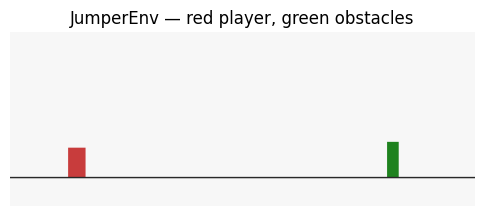

In [3]:
import matplotlib.pyplot as plt

env_rgb = JumperEnv(obs_mode="rgb", seed=42)
env_rgb.reset()
# take a few steps to make the scene less empty
for _ in range(20):
    env_rgb.step(0)
frame = env_rgb.render(mode="rgb_array")
env_rgb.close()

plt.figure(figsize=(6, 2.5))
plt.imshow(frame)
plt.axis("off")
plt.title("JumperEnv — red player, green obstacles")
plt.show()

## 4. Step 0 — play the game yourself

**Do this before training anything.** Build intuition for how hard
the timing is — when your agent later clears 40+ obstacles you'll
know what it's accomplishing, and when it doesn't, you'll have a
concrete sense of what the policy is missing.

From a terminal (not the notebook), run:

```bash
python -m arena.play
```

Controls: **SPACE** / **↑** to jump, **R** to restart after death,
**ESC** / **Q** to quit. The window title shows score, return, steps
survived, and your best score this session. Try to clear at least 5
obstacles — notice how much earlier you have to start the jump as
the world speed grows.

To watch a random rollout in a window instead:

```bash
python -m arena.demo
```

## 5. Onward

Once you've felt the env, head to
[`1-q_learning.ipynb`](1-q_learning.ipynb) to train a tabular
Q-learning agent.